# DETR vs. DETR-HYBRID-V2: Inference Comparison
This notebook provides a side-by-side comparison of the baseline **DETR** model, the **DETR-HYBRID-V2** model, and the **Ground Truth** annotations.

## Objectives:
1. **Qualitative:** Visualize detections vs. Ground Truth.
2. **Efficiency:** Compare inference latency and token reduction.
3. **Quantitative:** Compare AP/Recall metrics across categories.

In [42]:
import os
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt
import json
import random
from PIL import Image
from pathlib import Path

# --------------------------------------------------------------------------
# 1. GLOBAL CONFIGURATION & DATA LOADING
# --------------------------------------------------------------------------
root_dir = Path(os.getcwd())
detr_path = root_dir / 'code/DETR'
hybrid_path = root_dir / 'code/DETR-HYBRID-V2'
dataset_root = Path('/root/datasets/FASDD/FASDD_CV')
ann_path = dataset_root / 'annotations/COCO_CV/Annotations/test.json'

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Load Annotations Globally
if not ann_path.exists():
    raise FileNotFoundError(f"Annotations not found at {ann_path}")

with open(ann_path, 'r') as f:
    coco_data = json.load(f)

print(f"✓ Loaded {len(coco_data['images'])} image annotations into 'coco_data' variable.")

def get_ground_truth(image_name):
    """Helper to fetch boxes from global coco_data."""
    img_info = next((item for item in coco_data['images'] if item["file_name"] == image_name), None)
    if img_info is None: return []
    img_id = img_info['id']
    return [item for item in coco_data['annotations'] if item["image_id"] == img_id]

Using device: cuda
✓ Loaded 15884 image annotations into 'coco_data' variable.


## 2. Load Models
We load the latest checkpoints for both variants. 

**Crucial:** We use aggressive cache clearing to ensure the two models (which share the same module names) don't collide in memory.

In [43]:
def load_model(variant='baseline'):
    # 1. Aggressive cleanup of 'models', 'util', 'datasets' namespaces
    # This prevents the 'got unexpected keyword argument debug' error when switching variants.
    to_purge = [m for m in list(sys.modules.keys()) if m.startswith(('models', 'util', 'datasets'))]
    for m in to_purge: 
        del sys.modules[m]
    
    # 2. Path Isolation
    active_path = str(detr_path if variant == 'baseline' else hybrid_path)
    inactive_path = str(hybrid_path if variant == 'baseline' else detr_path)
    
    if active_path not in sys.path: sys.path.insert(0, active_path)
    if inactive_path in sys.path: sys.path.remove(inactive_path)
    
    # 3. Import and build from fresh context
    from models import build_model
    checkpoint_path = (detr_path if variant == 'baseline' else hybrid_path) / \
                     ('outputs/Pretrained-2/checkpoint.pth' if variant == 'baseline' else 'outputs/2-withwarmingepoch/checkpoint.pth')
        
    class Args:
        def __init__(self, v):
            self.lr_backbone = 1e-5
            self.backbone = 'resnet50'
            self.dilation = False
            self.position_embedding = 'sine'
            self.hidden_dim = 256
            self.enc_layers = 6
            self.dec_layers = 6
            self.dim_feedforward = 2048
            self.dropout = 0.1
            self.nheads = 8
            self.num_queries = 100
            self.pre_norm = False
            self.masks = False
            self.aux_loss = False
            self.dataset_file = 'coco'
            self.device = device
            self.num_classes = 2 
            
            # Required constants for Matcher/Criterion
            self.set_cost_class = 1
            self.set_cost_bbox = 5
            self.set_cost_giou = 2
            self.bbox_loss_coef = 5
            self.giou_loss_coef = 2
            self.eos_coef = 0.1
            self.mask_loss_coef = 1
            self.dice_loss_coef = 1
            self.frozen_weights = None
            
            if v == 'hybrid':
                self.hybrid_token_mode = 'mixed'
                self.slic_n_segments = 200
                self.pixel_prune = True
                self.pixel_prune_keep_ratio = 0.8
                self.pixel_prune_score_mode = 'saliency'
    
    args = Args(variant)
    model, _, _ = build_model(args)
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint['model'], strict=False)
    model.to(device).eval()
    
    return model

print("Loading Baseline DETR...")
model_detr = load_model('baseline')
print("Loading Hybrid-V2 DETR...")
model_hybrid = load_model('hybrid')
print("✓ Models loaded successfully.")

Loading Baseline DETR...
Loading Hybrid-V2 DETR...
✓ Models loaded successfully.


## 3. Visualize Comparison (Ground Truth vs. Models)
Select random images from the test set and compare models side-by-side.

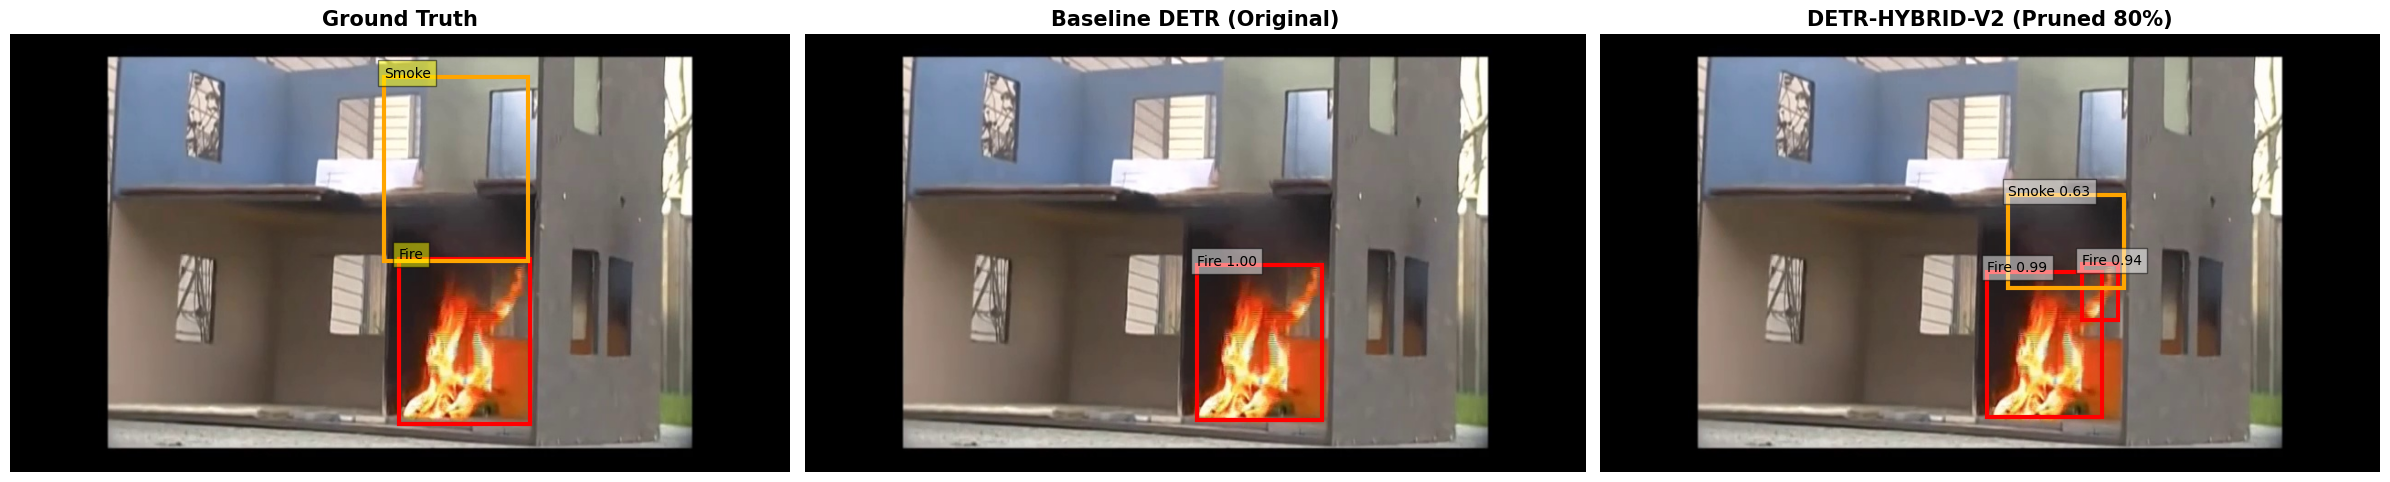

In [70]:
# Re-import required modules (safe-guard against cache clear in load_model)
import datasets.transforms as T
from util.misc import NestedTensor

def get_transform():
    return T.Compose([
        T.RandomResize([800], max_size=1333),
        T.ToTensor(),
        T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

def run_inference(model, image_path, is_hybrid=False):
    img = Image.open(image_path).convert('RGB')
    w, h = img.size
    
    slic_maps = {}
    if is_hybrid:
        sp_path = dataset_root / 'superpixels-200' / (Path(image_path).stem + '.npz')
        if sp_path.exists():
            with np.load(str(sp_path)) as data:
                slic_maps[200] = torch.from_numpy(data['sp_map'].astype(np.int64)).long()
    
    target = {'size': torch.tensor([h, w]), 'slic_maps': slic_maps}
    img_tensor, target = get_transform()(img, target)
    img_tensor = img_tensor.unsqueeze(0).to(device)
    mask = torch.zeros((1, img_tensor.shape[-2], img_tensor.shape[-1]), dtype=torch.bool, device=device)
    
    with torch.no_grad():
        outputs = model(NestedTensor(img_tensor, mask))
    return outputs, img

def plot_comparison(image_name):
    image_path = dataset_root / 'images' / image_name
    out_detr, img = run_inference(model_detr, image_path, False)
    out_hybrid, _ = run_inference(model_hybrid, image_path, True)
    anns = get_ground_truth(image_name)
    
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 8))
    colors = ['red', 'orange'] 
    names = ['Fire', 'Smoke']
    w, h = img.size
    
    # 1. Ground Truth
    ax1.imshow(img)
    for ann in anns:
        bbox = ann['bbox'] # [x, y, w, h]
        rect = plt.Rectangle((bbox[0], bbox[1]), bbox[2], bbox[3], fill=False, color=colors[ann['category_id']], linewidth=3)
        ax1.add_patch(rect)
        ax1.text(bbox[0], bbox[1], names[ann['category_id']], bbox=dict(facecolor='yellow', alpha=0.5))
    ax1.set_title("Ground Truth", fontweight='bold', fontsize=15)
    ax1.axis('off')
    
    # 2. Baseline DETR
    ax2.imshow(img)
    probs = out_detr['pred_logits'].softmax(-1)[0, :, :-1]
    keep = probs.max(-1).values > 0.5
    for box, prob in zip(out_detr['pred_boxes'][0, keep], probs[keep]):
        cx, cy, bw, bh = box.cpu()
        l, t = (cx - bw/2) * w, (cy - bh/2) * h
        label = prob.argmax().item()
        rect = plt.Rectangle((l, t), bw*w, bh*h, fill=False, color=colors[label], linewidth=3)
        ax2.add_patch(rect)
        ax2.text(l, t, f"{names[label]} {prob.max():.2f}", bbox=dict(facecolor='white', alpha=0.5))
    ax2.set_title("Baseline DETR (Original)", fontweight='bold', fontsize=15)
    ax2.axis('off')
    
    # 3. Hybrid V2
    ax3.imshow(img)
    probs = out_hybrid['pred_logits'].softmax(-1)[0, :, :-1]
    keep = probs.max(-1).values > 0.5
    for box, prob in zip(out_hybrid['pred_boxes'][0, keep], probs[keep]):
        cx, cy, bw, bh = box.cpu()
        l, t = (cx - bw/2) * w, (cy - bh/2) * h
        label = prob.argmax().item()
        rect = plt.Rectangle((l, t), bw*w, bh*h, fill=False, color=colors[label], linewidth=3)
        ax3.add_patch(rect)
        ax3.text(l, t, f"{names[label]} {prob.max():.2f}", bbox=dict(facecolor='white', alpha=0.5))
    ax3.set_title("DETR-HYBRID-V2 (Pruned 80%)", fontweight='bold', fontsize=15)
    ax3.axis('off')
    
    plt.tight_layout()
    plt.show()

# Get images with 'both' in name from test set
both_images = [img['file_name'] for img in coco_data['images'] if img['file_name'].startswith('both')]
plot_comparison(random.choice(both_images))

## 4. Efficiency Benchmarking
Comparison of average inference time over 10 iterations.

In [46]:
import time

def benchmark(model, image_path, is_hybrid, iters=10):
    # Warmup
    for _ in range(3): run_inference(model, image_path, is_hybrid)
    
    torch.cuda.synchronize()
    t0 = time.time()
    for _ in range(iters):
        run_inference(model, image_path, is_hybrid)
    torch.cuda.synchronize()
    return (time.time() - t0) / iters * 1000

sample_img_name = random.choice(both_images)
sample_img_path = dataset_root / 'images' / sample_img_name

ms_detr = benchmark(model_detr, sample_img_path, False)
ms_hybrid = benchmark(model_hybrid, sample_img_path, True)

print(f"Benchmarking on: {sample_img_name}")
print(f"Baseline Latency: {ms_detr:.2f} ms")
print(f"Hybrid Latency:   {ms_hybrid:.2f} ms")
print(f"Speedup:          {(ms_detr/ms_hybrid - 1)*100:.1f}%")

Benchmarking on: bothFireAndSmoke_CV013851.jpg
Baseline Latency: 31.83 ms
Hybrid Latency:   36.27 ms
Speedup:          -12.2%
